# Evaluation of Stochastic Offering Strategies for Wind Power in Day-Ahead Markets

In this section we will select distinct offers for the day-ahead market and evaluate their performance given real market and wind outcomes over multiple days. The evaluation will be based on the profit obtained from each strategy. For this we will consider the case of a One-Price imbalance settlement market.

Compared strategies include:


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_real = pd.read_parquet('../generated_scenarios/real_outcomes.parquet')

in_sample_scenarios = {}
out_of_sample_scenarios = {}
dates = df_real.index.get_level_values(0).strftime("%Y-%m-%d").unique()
for date in dates:
     scenarios = np.load(f'../generated_scenarios/scenarios_{date}.npy')
     in_sample_scenarios[date] = scenarios[:,:800,:]
     out_of_sample_scenarios[date] = scenarios[:,800:,:]

var_names = {'OffshoreWindPower': 'Offshore Wind Production (MW)', 
             'SpotPriceEUR': 'Spot Price (EUR/MWh)', 
             'DominatingDirection': 'Imbalance Direction (1, 0, -1)', 
             'ImbalancePriceEUR': 'Imbalance Price (EUR/MWh)'}

x_axis = df_real.index

In [ ]:
# from src.market import DayEvaluator, OnePriceModel, TwoPriceModel

# results = {date:[] for date in dates}
# ALPHA_CVAR = 0.95

# for date in dates:
#     df_real_date = df_real.loc[date].copy()

#     if len(df_real_date) != 96:
#         print(f"Warning: Date {date} has {len(df_real_date)} hours instead of 96. Skipping this date.")
#         continue

#     day_evaluator = DayEvaluator(date=date,
#                              imbalance_settlement='one_price',
#                              scenarios=in_sample_scenarios[date],
#                              df_real=df_real_date)
    
    
#     # Strategy 1 Forecasted day-ahead offer
#     p_da = df_real_date['ForecastDayAhead'].values
#     evaluation = day_evaluator.evaluate_strategy(p_DA = p_da,
#                                                  strategy_id='day_ahead_forecast',
#                                                  strategy_name='Offer Day-ahead forecast',
#                                                  others={},
#                                                  alpha_CVaR=ALPHA_CVAR)
#     results[date].append(evaluation)

#     # Strategy 2 Expected value offer
#     p_da = in_sample_scenarios[date][0,:,:].mean(axis=0)
#     evaluation = day_evaluator.evaluate_strategy(p_DA = p_da,
#                                                  strategy_id='expected_value_offer',
#                                                  strategy_name='Offer Expected Value',
#                                                  others={},
#                                                  alpha_CVaR=ALPHA_CVAR)
#     results[date].append(evaluation)

#     # Strategy 3 Production-quantile offer
#     quantiles = [0.25, 0.4, 0.6, 0.75]

#     for tau in quantiles:
#         p_da = np.quantile(in_sample_scenarios[date][0,:,:], tau, axis=0)
#         evaluation = day_evaluator.evaluate_strategy(p_DA = p_da,
#                                                      strategy_id=f'quantile_{tau}',
#                                                      strategy_name=f'Offer {int(tau*100)}% Quantile',
#                                                      others={'tau': tau},
#                                                      alpha_CVaR=ALPHA_CVAR)
#         results[date].append(evaluation)

#     # Strategy 4 Stochastic offer for One Price Model
#     alphas = [0.9, 0.975]
#     betas = [0.75, 1]
#     beta0 = 0

#     # first fit for beta=0 (no risk management)
#     one_price_model = OnePriceModel(in_sample_scenarios[date], P_max=500)
#     one_price_model.fit(beta=beta0)
#     evaluation = day_evaluator.evaluate_strategy(p_DA = one_price_model.p_DA_opt,
#                                                     strategy_id=f'one_price_beta_{beta0}',
#                                                     strategy_name=f'Max Profit and CVaR (No risk management)',
#                                                     others={'beta': beta0},
#                                                     alpha_CVaR=ALPHA_CVAR)
    
#     results[date].append(evaluation)

#     for alpa in alphas:
#         for beta in betas:
#             one_price_model = OnePriceModel(in_sample_scenarios[date], P_max=500)
#             one_price_model.fit(beta=beta, alpha=alpa)
#             evaluation = day_evaluator.evaluate_strategy(p_DA = one_price_model.p_DA_opt,
#                                                         strategy_id=f'one_price_beta_{beta}_alpha_{alpa}',
#                                                         strategy_name=f'Max Profit and CVaR (alpha={alpa}, beta={beta})',
#                                                         others={'beta': beta, 'alpha': alpa},
#                                                         alpha_CVaR=ALPHA_CVAR)
#             results[date].append(evaluation)

    
#     # Strategy 5 Stochastic offer for Two Price Model, but evaluated in One Price Model

#     # first fit for beta=0 (no risk management)
#     two_price_model = TwoPriceModel(in_sample_scenarios[date], P_max=500)
#     two_price_model.fit(beta=beta0)
#     evaluation = day_evaluator.evaluate_strategy(p_DA = two_price_model.p_DA_opt,
#                                                     strategy_id=f'two_price_beta_{beta0}',
#                                                     strategy_name=f'Max Profit and CVaR Two Price Model (No risk management)',
#                                                     others={'beta': beta0},
#                                                     alpha_CVaR=ALPHA_CVAR)
#     results[date].append(evaluation)

#     for alpa in alphas:
#         for beta in betas:
#             two_price_model = TwoPriceModel(in_sample_scenarios[date], P_max=500)
#             two_price_model.fit(beta=beta, alpha=alpa)
#             evaluation = day_evaluator.evaluate_strategy(p_DA = two_price_model.p_DA_opt,
#                                                         strategy_id=f'two_price_beta_{beta}_alpha_{alpa}',
#                                                         strategy_name=f'Max Profit and CVaR Two Price Model (alpha={alpa}, beta={beta})',
#                                                         others={'beta': beta, 'alpha': alpa},
#                                                         alpha_CVaR=ALPHA_CVAR)
#             results[date].append(evaluation)




In [ ]:
# # save results object
# import pickle
# with open('../results/strategy_evaluation_results.pkl', 'wb') as f:
#     pickle.dump(results, f)

In [5]:
# load results object
import pickle
with open('../results/strategy_evaluation_results.pkl', 'rb') as f:
    results = pickle.load(f)

In [6]:
import dataclasses

# Fields that are arrays — keep them out of the flat DataFrame
_EXCLUDE = {'p_DA', 'profit_per_scenario', 'details'}

records = [
    {'date': date, **{k: v for k, v in dataclasses.asdict(r).items() if k not in _EXCLUDE}}
    for date, strats in results.items()
    for r in strats
]

df_results = pd.DataFrame(records)

df_results['date'] = pd.to_datetime(df_results['date'])

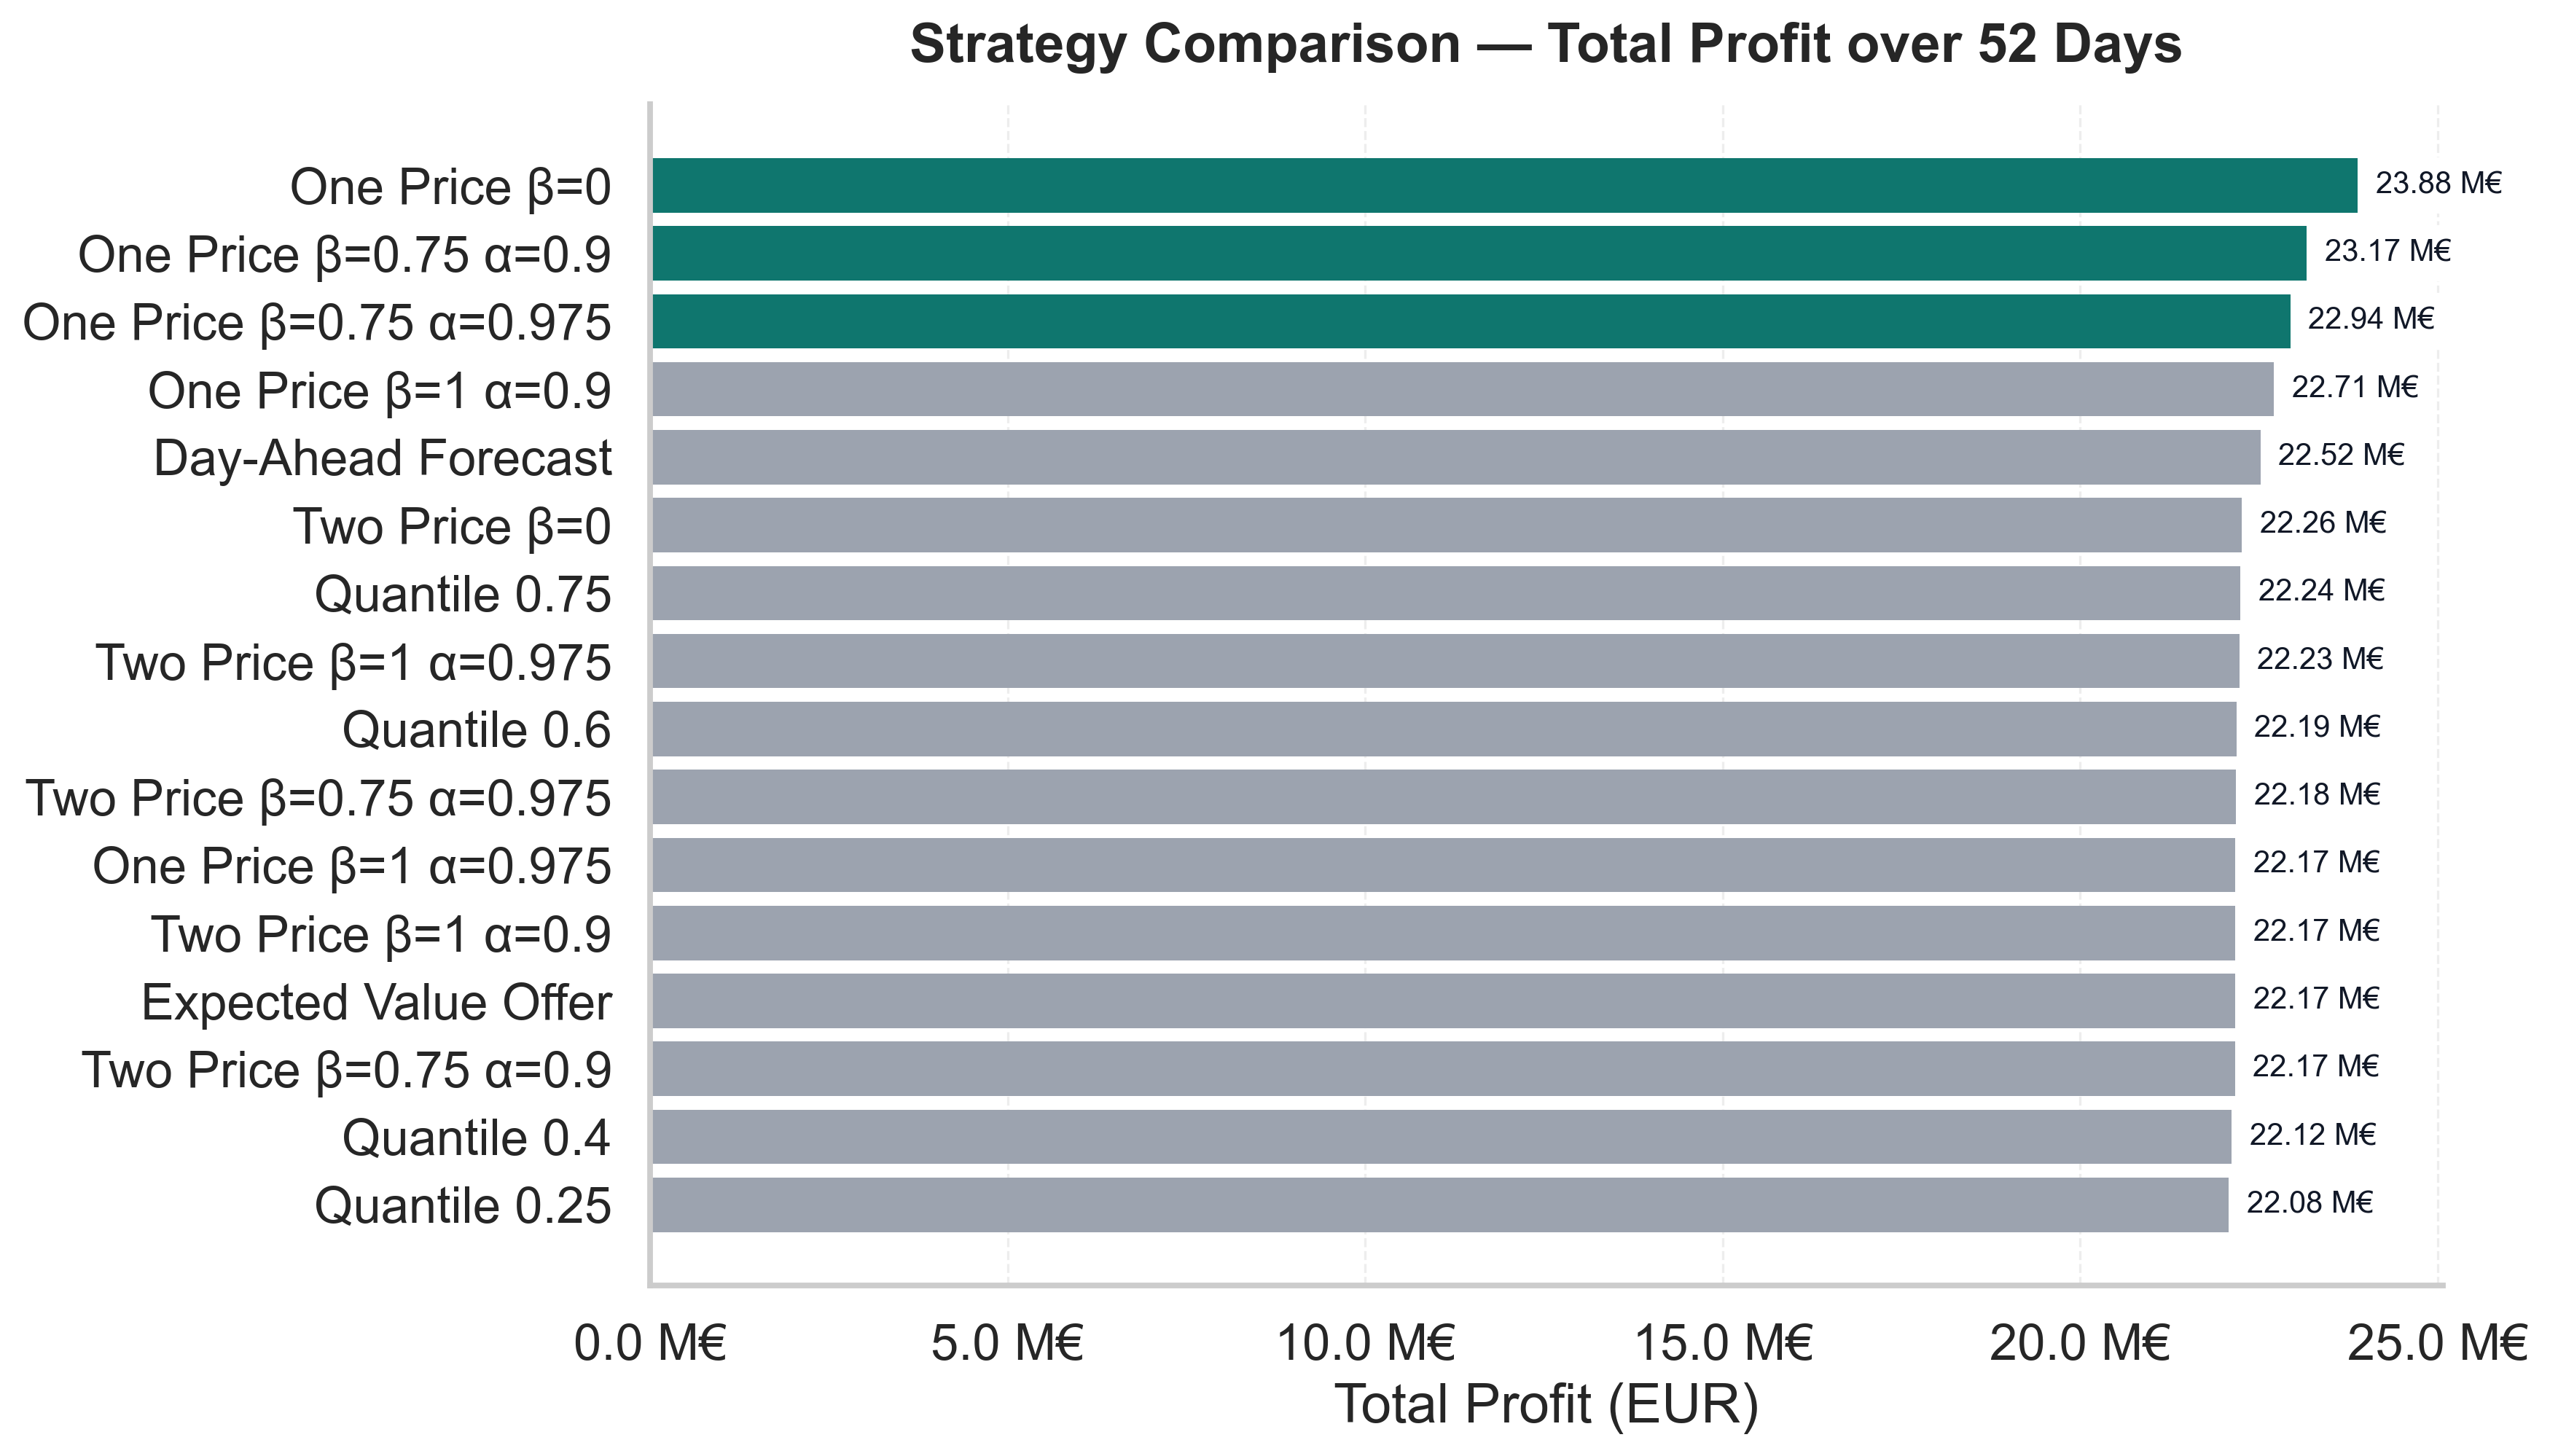

In [7]:
# Plot Results
from matplotlib.ticker import FuncFormatter

# 1) Build daily profit per strategy, then sum over all days
daily = (
    df_results.groupby(["strategy_id", "date"], as_index=False)["profit_real"]
    .sum()
)

n_days = df_results['date'].nunique()

summary = (
    daily.groupby(["strategy_id"], as_index=False)
    .agg(
        total_profit=("profit_real", "sum"),
        n_days=("date", "nunique"),
    )
)

def format_label(s):
    s = s.replace("alpha_", "α=").replace("beta_", "β=")
    s = s.replace("_", " ").replace("one price", "One Price").replace("two price", "Two Price")
    s = s.replace("quantile", "Quantile").replace("day ahead forecast", "Day-Ahead Forecast")
    s = s.replace("expected value offer", "Expected Value Offer")
    return s

summary["label"] = summary["strategy_id"].apply(format_label)
summary = summary.sort_values("total_profit", ascending=False).reset_index(drop=True)

# 2) Styling
sns.set_theme(style="whitegrid", context="talk")
fig, ax = plt.subplots(figsize=(12, 7), dpi=300)

base_color = "#9CA3AF"
highlight_color = "#0F766E"
colors = [highlight_color if i < 3 else base_color for i in range(len(summary))]

bars = ax.barh(
    y=summary["label"],
    width=summary["total_profit"],
    color=colors,
    edgecolor="none",
)

ax.invert_yaxis()

ax.set_title(f"Strategy Comparison — Total Profit over {n_days} Days", pad=14, weight="bold")
ax.set_xlabel("Total Profit (EUR)")
ax.set_ylabel("")

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1e6:,.1f} M€"))
ax.grid(axis="x", linestyle="--", linewidth=0.8, alpha=0.35)
ax.grid(axis="y", visible=False)

x_min_ax, x_max_ax = ax.get_xlim()
offset = 0.01 * (x_max_ax - x_min_ax)

for bar, val in zip(bars, summary["total_profit"]):
    y_pos = bar.get_y() + bar.get_height() / 2
    x_pos = bar.get_width()
    ax.text(
        x_pos + offset, y_pos,
        f"{val/1e6:,.2f} M€",
        va="center", ha="left", fontsize=10,
        color="#111827", backgroundcolor="white",
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()
